In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import sys
from pathlib import Path

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score


### For this iteration, we are removing all weather features to see how the model performs. This will help us to compare any bias that may had been occuring from the weather features since the data only merged for about 30 airports. 

Ensure to run file "RF_Feature_Engineering.ipynb" in path 2b_feature_engineering prior to this notebook to populate featureset.

In [4]:
df = pd.read_parquet("../../../1_download_data/model_ready/RF_V1.parquet")
df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,DOT_ID_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginWac,DestAirportID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestWac,DepTimeBlk,ArrTimeBlk,DistanceGroup,target,is_holiday,date,dep_hour,is_morning_peak,is_evening_peak
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,1202,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,20363,N8928A,3298,10146,30146,"Albany, GA",GA,13,34,10397,30397,"Atlanta, GA",GA,13,34,1200-1259,1300-1359,1,On time,0,2018-01-23,12,0,0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,1202,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,20363,N800AY,3298,10146,30146,"Albany, GA",GA,13,34,10397,30397,"Atlanta, GA",GA,13,34,1200-1259,1300-1359,1,On time,0,2018-01-24,12,0,0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,1202,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,20363,N8836A,3298,10146,30146,"Albany, GA",GA,13,34,10397,30397,"Atlanta, GA",GA,13,34,1200-1259,1300-1359,1,On time,0,2018-01-25,12,0,0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,1202,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,20363,N800AY,3298,10146,30146,"Albany, GA",GA,13,34,10397,30397,"Atlanta, GA",GA,13,34,1200-1259,1300-1359,1,On time,0,2018-01-26,12,0,0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,1400,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,20363,N8839E,3298,10146,30146,"Albany, GA",GA,13,34,10397,30397,"Atlanta, GA",GA,13,34,1400-1459,1500-1559,1,On time,0,2018-01-27,14,0,0


In [5]:
df.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'CRSDepTime', 'Distance',
       'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'DOT_ID_Marketing_Airline', 'DOT_ID_Operating_Airline', 'Tail_Number',
       'Flight_Number_Operating_Airline', 'OriginAirportID',
       'OriginCityMarketID', 'OriginCityName', 'OriginState',
       'OriginStateFips', 'OriginWac', 'DestAirportID', 'DestCityMarketID',
       'DestCityName', 'DestState', 'DestStateFips', 'DestWac', 'DepTimeBlk',
       'ArrTimeBlk', 'DistanceGroup', 'target', 'is_holiday', 'date',
       'dep_hour', 'is_morning_peak', 'is_evening_peak'],
      dtype='object')

In [6]:
# Train on 2018
train_df = df[df["Year"] == 2018]

# Test on 2019
test_df = df[df["Year"] == 2019]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (5689512, 38)
Test shape: (8091684, 38)


In [7]:
# Split features and target
X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

### Let's start to build up our model one feature at a time

In [8]:
# Encode target to integers
le_target = LabelEncoder()
df['target_enc'] = le_target.fit_transform(df['target'])


In [9]:
# Assume these are your columns
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'target_enc']

categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features = [col for col in categorical_features if col != 'target']


In [10]:
from sklearn.feature_selection import f_classif

X_num = df[numeric_features]
y = df['target_enc']
X_num = X_num.fillna(0)



In [11]:
f_vals, p_vals = f_classif(X_num, y)
numeric_corr = pd.Series(f_vals, index=numeric_features).sort_values(ascending=False)

In [12]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    phi2 = chi2/n
    r,k = contingency.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

categorical_corr = {}
for col in categorical_features:
    categorical_corr[col] = cramers_v(df[col], df['target_enc'])

categorical_corr = pd.Series(categorical_corr).sort_values(ascending=False)


In [13]:
all_corr = pd.concat([numeric_corr, categorical_corr])
all_corr = all_corr.sort_values(ascending=False)
print("Top correlated features with target:")
print(all_corr.head(10))


Top correlated features with target:
CRSDepTime                         343985.161062
dep_hour                           342692.538861
is_morning_peak                    211262.459561
is_evening_peak                    197795.242286
Month                               22043.724503
Quarter                             20849.611081
DistanceGroup                       13768.208173
Distance                            13563.927457
DOT_ID_Operating_Airline            13549.108327
Flight_Number_Operating_Airline     11068.265860
dtype: float64


In [14]:
all_corr[0:20].index

Index(['CRSDepTime', 'dep_hour', 'is_morning_peak', 'is_evening_peak', 'Month',
       'Quarter', 'DistanceGroup', 'Distance', 'DOT_ID_Operating_Airline',
       'Flight_Number_Operating_Airline', 'Year', 'OriginCityMarketID',
       'DestWac', 'OriginWac', 'OriginStateFips', 'OriginAirportID',
       'DestStateFips', 'is_holiday', 'DestCityMarketID', 'DayOfWeek'],
      dtype='object')

Now lets iterate through some variables to see results of performance

In [15]:
FEATURES = all_corr[0:8].index.tolist()
            
print(FEATURES)
TARGET = "target"




['CRSDepTime', 'dep_hour', 'is_morning_peak', 'is_evening_peak', 'Month', 'Quarter', 'DistanceGroup', 'Distance']


In [16]:
type(df.CRSDepTime[0])

numpy.int64

In [17]:
df[FEATURES]

,CRSDepTime,dep_hour,is_morning_peak,is_evening_peak,Month,Quarter,DistanceGroup,Distance
0,1202,12,0,0,1,1,1,145.0
1,1202,12,0,0,1,1,1,145.0
2,1202,12,0,0,1,1,1,145.0
3,1202,12,0,0,1,1,1,145.0
4,1400,14,0,0,1,1,1,145.0
...,...,...,...,...,...,...,...,...
24171380,1949,19,0,1,3,1,5,1167.0
24171381,1733,17,0,1,3,1,3,529.0
24171382,1700,17,0,1,3,1,3,723.0
24171383,2129,21,0,1,3,1,2,319.0


In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
# categorical_features = [
#     "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
# ]

numeric_features = ['CRSDepTime', 'dep_hour', 'is_morning_peak', 'is_evening_peak', 'Month', 'Quarter', 'DistanceGroup', 'Distance']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
       # ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [19]:
rf_model = RandomForestClassifier(class_weight="balanced",
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)

In [20]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])

In [21]:
for col in numeric_features:
    X_train[col] = X_train[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)


In [22]:
pipeline.fit(X_train[FEATURES], y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['CRSDepTime', 'dep_hour',
                                                   'is_morning_peak',
                                                   'is_evening_peak', 'Month',
                                                   'Quarter', 'DistanceGroup',
                                                   'Distance'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [23]:
# Predictions
y_pred = pipeline.predict(X_test[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)


Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.030     0.316     0.054    153629
     Delayed      0.248     0.487     0.329   1484629
     On time      0.861     0.472     0.610   6453426

    accuracy                          0.472   8091684
   macro avg      0.380     0.425     0.331   8091684
weighted avg      0.733     0.472     0.548   8091684


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.315637  0.354139  0.330224
Delayed     0.216104  0.487194  0.296702
On time     0.196575  0.331589  0.471836


Test Accuracy: 0.472

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled      48491    54406    50732
Delayed       320835   723302   440492
On time      1268583  2139887  3044956


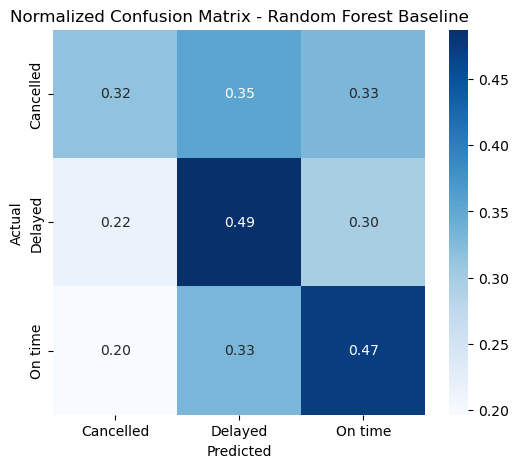

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(X_test[FEATURES])
y_true = y_test

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)
# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

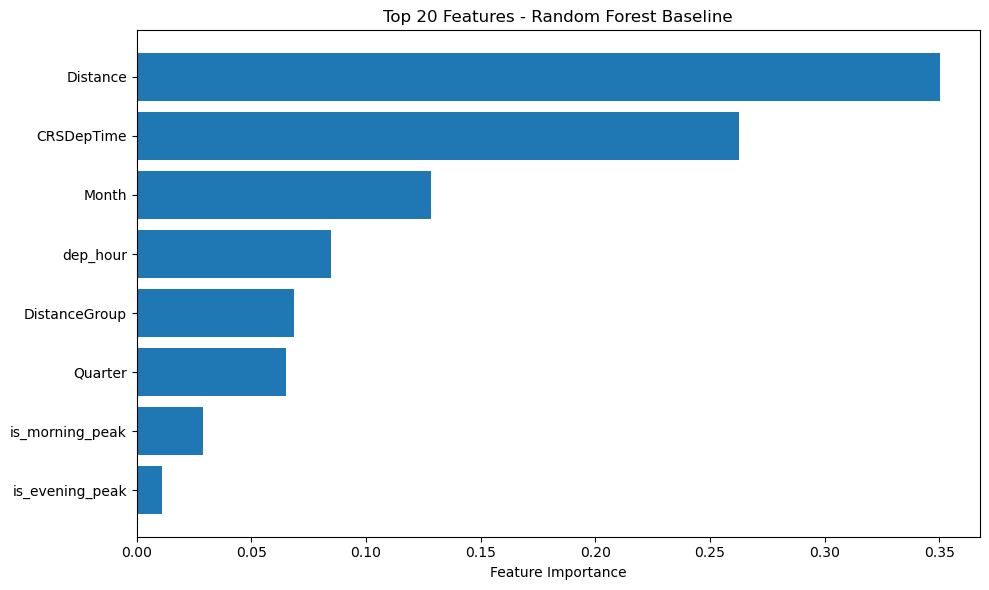

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
#cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
#all_features = np.concatenate([cat_features, numeric_features])
all_features = np.array(numeric_features)

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 8
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()

## Iterate through features while adding features

In [33]:
# Suppose all_corr is a pandas Series of correlations sorted descending
# Example: all_corr = df.corr()['target'].sort_values(ascending=False)

feature_list = []

# Loop through feature counts, e.g., 10 to 24
for i in range(10, 25):
    # Take top i features (excluding the target if included)
    top_features = all_corr.index[:i].tolist()  # returns a list
    feature_list.append(top_features)

In [34]:
# Assume these are your columns
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'target_enc']

categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features = [col for col in categorical_features if col != 'target']

In [35]:
results = []

for features in feature_list:
    print(f"Starting training for:{len(features)} Features")
    #print(f"{len(features)} Features: Training model with: {features}")
    
    # Split the feature subset into numeric and categorical columns
    num_feats = [f for f in features if f in numeric_features]
    cat_feats = [f for f in features if f in categorical_features]
    
    # Define the preprocessor for this subset
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_feats),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
        ]
    )
    
    # Create the pipeline: preprocessor + RandomForest
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight="balanced",
            n_estimators=80,
            max_depth=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        ))
    ])
    
    # Train
    print("Training Model")
    pipeline.fit(X_train[features], y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test[features])
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    macro_precision = precision_score(y_test, y_pred, average="macro")
    macro_recall = recall_score(y_test, y_pred, average="macro")

    print("Classification Report Started")
    # Classification report for per-class F1
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Append results
    results.append({
        "num_features": len(features),
        "features_used": ", ".join(features),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "Cancelled_f1": report.get("Cancelled", {}).get("f1-score", None),
        "Delayed_f1": report.get("Delayed", {}).get("f1-score", None),
        "On-Time_f1": report.get("On-Time", {}).get("f1-score", None)
    })


Starting training for:10 Features
Training Model
Classification Report Started
Starting training for:11 Features
Training Model
Classification Report Started
Starting training for:12 Features
Training Model
Classification Report Started
Starting training for:13 Features
Training Model
Classification Report Started
Starting training for:14 Features
Training Model
Classification Report Started
Starting training for:15 Features
Training Model
Classification Report Started
Starting training for:16 Features
Training Model
Classification Report Started
Starting training for:17 Features
Training Model
Classification Report Started
Starting training for:18 Features
Training Model
Classification Report Started
Starting training for:19 Features
Training Model
Classification Report Started
Starting training for:20 Features
Training Model
Classification Report Started
Starting training for:21 Features
Training Model
Classification Report Started
Starting training for:22 Features
Training Model
Cla

In [36]:
# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df = results_df.round({
    'accuracy': 2,
    'macro_f1': 2,
    'weighted_f1': 2,
    'macro_precision': 2,
    'macro_recall': 2,
    'Cancelled_f1': 2,
    'Delayed_f1': 2,
    'On-Time_f1': 2
})

# Optional: sort by Macro F1
results_df = results_df.sort_values("macro_f1", ascending=False)

# Display top results
results_df.head()

,num_features,features_used,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,Cancelled_f1,Delayed_f1,On-Time_f1
10,20,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.55,0.37,0.61,0.39,0.46,0.07,0.33,None
12,22,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.57,0.37,0.63,0.39,0.44,0.07,0.34,None
13,23,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.58,0.37,0.64,0.39,0.44,0.07,0.33,None
2,12,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.53,0.36,0.60,0.39,0.45,0.07,0.32,None
3,13,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.54,0.36,0.61,0.39,0.46,0.07,0.33,None


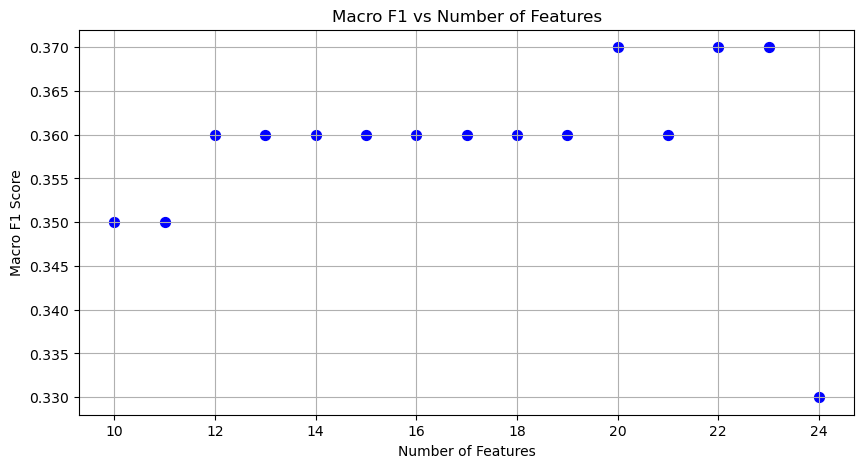

In [37]:
plt.figure(figsize=(10,5))
plt.scatter(results_df["num_features"], results_df["macro_f1"], color="blue", s=50)  # s=marker size
plt.xlabel("Number of Features")
plt.ylabel("Macro F1 Score")
plt.title("Macro F1 vs Number of Features")
plt.grid(True)
plt.show()

In [38]:
results_df

,num_features,features_used,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,Cancelled_f1,Delayed_f1,On-Time_f1
10,20,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.55,0.37,0.61,0.39,0.46,0.07,0.33,None
12,22,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.57,0.37,0.63,0.39,0.44,0.07,0.34,None
13,23,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.58,0.37,0.64,0.39,0.44,0.07,0.33,None
2,12,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.53,0.36,0.60,0.39,0.45,0.07,0.32,None
3,13,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.54,0.36,0.61,0.39,0.46,0.07,0.33,None
4,14,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.53,0.36,0.61,0.39,0.46,0.07,0.33,None
5,15,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.53,0.36,0.60,0.39,0.46,0.07,0.33,None
6,16,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.54,0.36,0.61,0.39,0.46,0.07,0.33,None
7,17,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.54,0.36,0.61,0.39,0.46,0.07,0.33,None
8,18,"CRSDepTime, dep_hour, is_morning_peak, is_even...",0.53,0.36,0.60,0.39,0.46,0.07,0.33,None


From here we can see that the model is not performing too well:

Overall Observations

- num_features ranges from 10 → 24.
- Accuracy is around 0.53–0.58 for most subsets, except the last row (24 features) drops to 0.46.
- macro_f1 is low (0.35–0.37), indicating poor performance on minority classes.
- weighted_f1 is higher (0.60–0.64), which makes sense because the majority class (On-Time) dominates, so weighted F1 is inflated.
- Cancelled_f1 is extremely low (0.06–0.07) → model is struggling to detect cancellations.
- Delayed_f1 is slightly better (0.32–0.34).
- On-Time_f1 is missing (None), probably because of a label mismatch or empty predictions.

Overall, we can see how:
- Top 10–13 features capture most predictive power.
- Macro F1 is low → model needs better handling of minority classes.
- Cancelations are extremely underpredicted → need SMOTE / Balanced RF / class_weight.
- Extra features beyond 13 hurt performance → feature selection matters.

Let us explore XGBoost since it is performing better. 